# **The Geography of Payments: Mapping Consumer Financial Preferences Across Urban Centers.**

## **Dataset Decription**
1) Order ID: A unique identifier for each sales order. This can be used to track individual transactions.

2) Order Date: The date when the order was placed. This column is essential for time-series analysis, such as identifying sales trends over time or seasonality.

3) Product: The name or type of the product sold. This column is crucial for analyzing sales performance by product category.

4) Price : The unit price of the product. This, along with 'Quantity Ordered', is used to calculate the total price of each order.

5) Quantity : The number of units of the product sold in a single order. This is a key metric for calculating revenue and understanding sales volume.

6) Purchase Type : The order was made online or in-store or drive-thru.

7) Payment Method : How the payment for the order was done.

8) Manager : Name of the manager of the store.

9) City : The location of the store. This can be used for geographical analysis of sales, such as identifying top-performing regions or optimizing logistics

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("Dataset.xlsx")
df

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London,2000.0143
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid,2199.9920
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon,999.9960
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin,7400.0133
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin,2000.0495
...,...,...,...,...,...,...,...,...,...,...
249,10709,28-12-2022,Sides & Other,4.99,200.40,Drive-thru,Gift Card,Walter Muller,Berlin,999.9960
250,10710,29-12-2022,Burgers,12.99,754.43,Drive-thru,Gift Card,Walter Muller,Berlin,9800.0457
251,10711,29-12-2022,Chicken Sandwiches,9.95,281.41,Drive-thru,Gift Card,Walter Muller,Berlin,2800.0295
252,10712,29-12-2022,Fries,3.49,630.37,Drive-thru,Gift Card,Walter Muller,Berlin,2199.9913


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        254 non-null    int64  
 1   Date            254 non-null    object 
 2   Product         254 non-null    object 
 3   Price           254 non-null    float64
 4   Quantity        254 non-null    float64
 5   Purchase Type   254 non-null    object 
 6   Payment Method  254 non-null    object 
 7   Manager         254 non-null    object 
 8   City            254 non-null    object 
 9   Revenue         254 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 20.0+ KB


# **Data Quality Checking**

Tahap ini dilakukan untuk memastikan bagaiman keadaan data yang akan digunakan. Langkah yang dilakukan memeriksa tipe data untuk masing masing kolom

In [4]:
kolom = df.columns
kolom

Index(['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type',
       'Payment Method', 'Manager', 'City', 'Revenue'],
      dtype='object')

In [5]:
df.dtypes

Order ID            int64
Date               object
Product            object
Price             float64
Quantity          float64
Purchase Type      object
Payment Method     object
Manager            object
City               object
Revenue           float64
dtype: object

In [6]:
df.dtypes.value_counts()

object     6
float64    3
int64      1
Name: count, dtype: int64

In [7]:
df.isnull().sum()

Order ID          0
Date              0
Product           0
Price             0
Quantity          0
Purchase Type     0
Payment Method    0
Manager           0
City              0
Revenue           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

### **1. City**

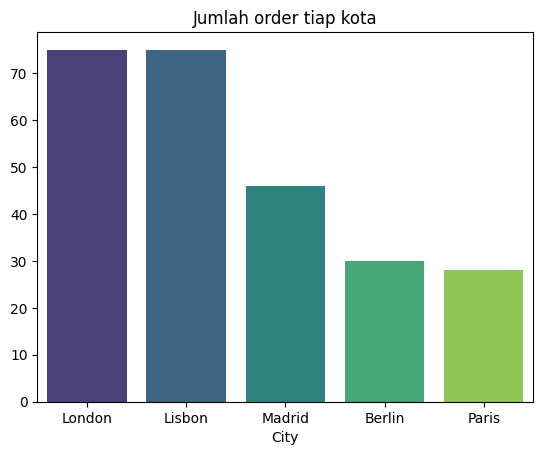

In [9]:
city_counts = df['City'].value_counts()
sns.barplot(x=city_counts.index, y=city_counts.values, hue=city_counts.index, palette='viridis', legend=False)
plt.title('Jumlah order tiap kota')
plt.show()

In [10]:
df.City.value_counts()

City
London    75
Lisbon    75
Madrid    46
Berlin    30
Paris     28
Name: count, dtype: int64

Berdasarkan plot diatas **London** dan **Lisbon** menjadi kota dengan jumlah order tertinggi sebanyak 75 order & kota dengan order terendah adalah **Paris** sebanyak 28 order

### **2. Purchase Type**

In [11]:
Purch_Type_by_City = pd.crosstab(df['Purchase Type'],df.City)
Purch_Type_by_City

City,Berlin,Lisbon,London,Madrid,Paris
Purchase Type,,,,,
Drive-thru,10,8,11,20,12
In-store,20,35,0,25,6
Online,0,32,64,1,10


Berdasarkan purchase type kota dengan purchase type menggunakan Drive-thru paling banyak ada di Madrid. Purchase Type untuk In-store paling banyak di kota Lisbon dan Purchase menggunakan online paling banyak dilakukan di kota London

### **3. Payment Method**

In [12]:
Payment_adoption_rate = pd.crosstab(df.City, df['Payment Method'], normalize ='index')*100
Payment_adoption_rate

Payment Method,Cash,Credit Card,Gift Card
City,,,
Berlin,53.333333,10.000000,36.666667
Lisbon,54.666667,12.000000,33.333333
London,8.000000,64.000000,28.000000
Madrid,2.173913,95.652174,2.173913
Paris,42.857143,57.142857,0.000000


Berdasarkan tabel adoption rate diatas didapatkan bahwa
* **Lisbon** merupakan kota yang menggunakan metode pembayaran Cash terbanyak dengan nilai adoption rate sebesar 54.666667
* Sedangkan metode pembayaran Credit Card paling banyak digunakan di kota **Madrid** dengan nilai adoption rate sebesar 95.652174
* Untuk pembayaran menggunakan Gift Card paling banyak digunakan di kota **Berlin**
* Fakta menarik ditemukan tidak ada pembayaran menggunakan Gift Card di kota **Paris**

### **4. Payment-Purchase Correlation**

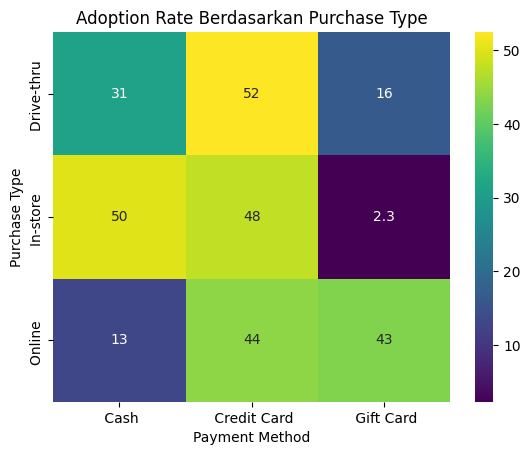

In [13]:
purchase_payment_ct = pd.crosstab(df['Purchase Type'],
                                  df['Payment Method'],
                                  normalize='index') * 100
sns.heatmap(purchase_payment_ct, annot=True, cmap='viridis')
plt.title('Adoption Rate Berdasarkan Purchase Type')
plt.show()

Berdasarkan grafik diatas didapatkan
* Pembelian yang dilakukan secara Drive-thru paling banyak menggunakan metode pembayaran Credit card
* Pembelian yang dilakukan secara in-store paling banyak menggunakan metode pembayaran Cash
* Pembelian yang dilakukan secara online paling banyak menggunakan metode pembayaran Credit card

## **Simpulan Awal**

* Kota paling banyak menerima order adalah London & Lisbon
* Berdasarkan tipe pembelian Lisbon paling banyak melakukan pembelian secara langsung (In Store) dan London paling banyak melakukan pembelian secara online. Hal ini juga sesuai dengan analisis pada subbab 3 yang menyatakan bahwa Lisbon merupakan kota yang menggunakan metode pembayaran Cash terbanyak dengan nilai adoption rate sebesar 54.666667
* Kota dengan jumlah order terendah adalah Paris

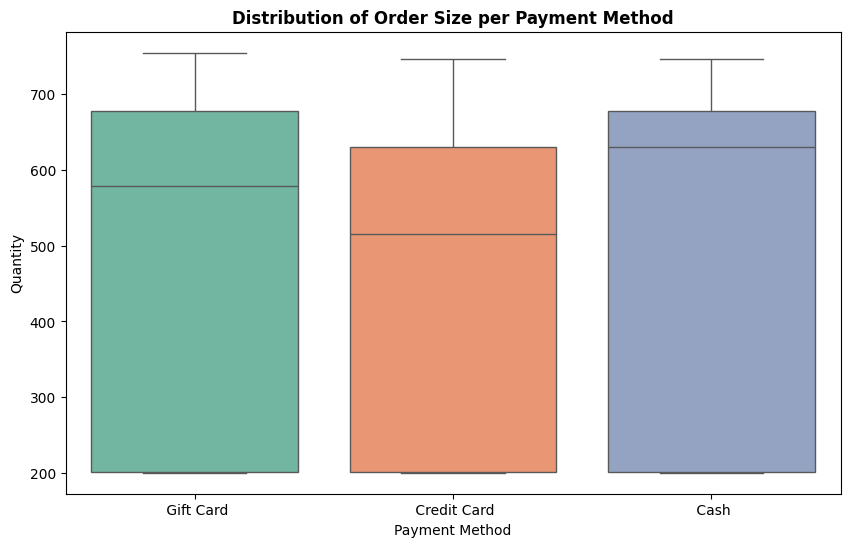

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Payment Method', y='Quantity', data=df, hue = 'Payment Method', palette='Set2')
plt.title('Distribution of Order Size per Payment Method', fontweight='bold')
plt.show()

<p align="justify"> Secara keseluruhan, metode pembayaran Cash cenderung digunakan untuk transaksi dengan jumlah barang (Quantity) yang lebih besar dibandingkan metode lainnya, terlihat dari garis mediannya yang paling tinggi. Meskipun metode Gift Card dan Cash memiliki rentang jumlah pembelian yang serupa (antara 200 hingga 750 unit), pengguna Cash secara konsisten melakukan pembelian dalam volume yang lebih besar di titik tengah distribusinya. Pengguna Credit Card tercatat memiliki median jumlah barang terendah dibandingkan Cash dan Gift Card. Hal ini menunjukkan bahwa di dataset ini, kartu kredit lebih sering digunakan untuk transaksi retail yang lebih kecil atau satuan dibandingkan pembelian dalam jumlah besar (bulk). Ketiga metode pembayaran menunjukkan variasi (interquartile range) yang sangat luas, yang berarti perilaku pembeli sangat beragam di setiap metode pembayaran, mulai dari pembelian minimum 200 hingga maksimum di atas 700 unit.</p>

In [15]:
import pandas as pd
from scipy import stats

# 1. Menyiapkan data berdasarkan grup
group_cash = df[df['Payment Method'] == ' Cash']['Quantity']
group_gift = df[df['Payment Method'] == ' Gift Card']['Quantity']
group_credit = df[df['Payment Method'] == ' Credit Card']['Quantity']

# 2. Menjalankan One-Way ANOVA
f_stat, p_value = stats.f_oneway(group_cash, group_gift, group_credit)

print(f"Hasil Uji ANOVA:")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

# 3. Interpretasi
if p_value < 0.05:
    print("\nKESIMPULAN: Perbedaan Signifikan!")
    print("Metode pembayaran berpengaruh nyata terhadap jumlah barang yang dibeli.")
else:
    print("\nKESIMPULAN: Tidak Signifikan.")
    print("Perbedaan rata-rata antar metode pembayaran kemungkinan besar hanya faktor kebetulan.")

Hasil Uji ANOVA:
F-Statistic: 0.9081
P-Value: 0.4046

KESIMPULAN: Tidak Signifikan.
Perbedaan rata-rata antar metode pembayaran kemungkinan besar hanya faktor kebetulan.


Berdasarkan uji One-Way ANOVA, ditemukan bahwa perbedaan rata-rata kuantitas pembelian antar metode pembayaran (Cash, Credit Card, Gift Card) tidak signifikan secara statistik (P-Value > 0.05).
* Perilaku Seragam: Ternyata, cara pelanggan membayar tidak membatasi seberapa banyak mereka berbelanja. Pelanggan yang membawa kartu kredit belanja sama banyaknya dengan mereka yang membawa uang tunai.
* Faktor Lain Lebih Dominan: Karena metode pembayaran tidak berpengaruh signifikan, maka faktor lain seperti Lokasi (City) atau Kategori Produk mungkin memiliki pengaruh yang jauh lebih kuat terhadap order size.